In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
X, y = make_blobs(n_samples=200, n_features=2, centers=4, center_box=(-4,4), random_state=17)

In [3]:
y


array([0, 0, 2, 2, 3, 1, 2, 1, 3, 3, 3, 0, 2, 0, 1, 2, 3, 0, 3, 0, 3, 0,
       2, 1, 2, 2, 3, 3, 0, 1, 1, 2, 3, 0, 1, 1, 1, 0, 3, 3, 2, 2, 0, 1,
       1, 1, 2, 3, 2, 3, 2, 1, 0, 1, 2, 3, 2, 2, 0, 2, 1, 2, 0, 0, 0, 1,
       3, 2, 3, 3, 0, 1, 2, 0, 2, 1, 3, 2, 0, 3, 0, 3, 0, 0, 2, 0, 3, 3,
       0, 2, 0, 1, 2, 0, 1, 3, 1, 0, 2, 1, 0, 1, 0, 1, 2, 1, 3, 0, 1, 3,
       0, 2, 1, 2, 1, 0, 0, 2, 1, 3, 0, 0, 3, 1, 2, 3, 1, 3, 1, 3, 1, 2,
       0, 3, 1, 2, 2, 3, 0, 3, 2, 1, 2, 1, 3, 2, 0, 1, 2, 0, 2, 0, 1, 0,
       3, 0, 3, 1, 2, 1, 1, 3, 3, 3, 3, 3, 2, 0, 0, 3, 1, 2, 0, 0, 3, 0,
       2, 0, 1, 2, 2, 2, 1, 0, 3, 0, 1, 1, 1, 3, 3, 3, 1, 2, 2, 1, 1, 2,
       3, 3])

In [4]:
plt.scatter

<function matplotlib.pyplot.scatter(x, y, s=None, c=None, marker=None, cmap=None, norm=None, vmin=None, vmax=None, alpha=None, linewidths=None, *, edgecolors=None, plotnonfinite=False, data=None, **kwargs)>

### 1. Plot a scatter plot with colors for each cluster

[make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) 

[scatter_plot](https://matplotlib.org/3.3.3/api/_as_gen/matplotlib.pyplot.scatter.html) 

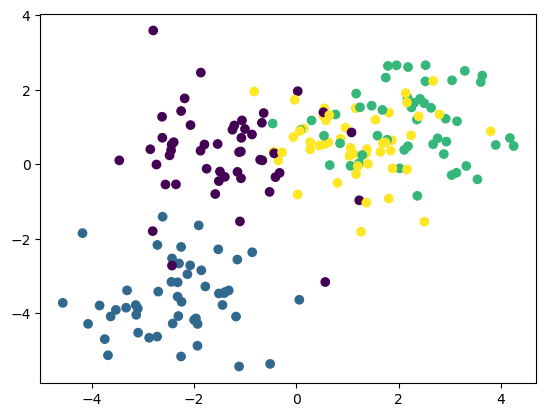

In [5]:
plt.scatter(X[:,0], X[:,1], c=y)

### K-Means clustering 

K-means clustering is an unsupervised machine learning algorithm used to partition a dataset into K distinct, non-overlapping subsets or clusters. The algorithm follows these steps:

1. **Initialization**: Randomly select K initial centroids from the dataset.
2. **Assignment**: Assign each data point to the nearest centroid, forming K clusters.
3. **Update**: Calculate the new centroids as the mean of all data points assigned to each cluster.
4. **Repeat**: Repeat the assignment and update steps until the centroids no longer change significantly or a maximum number of iterations is reached.

The goal of K-means is to minimize the within-cluster sum of squares (inertia), which measures the compactness of the clusters.

### 2. Fit a K-Means algorithm with different values for center and plot result


[k-means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

Bonus: plot computed centroids

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


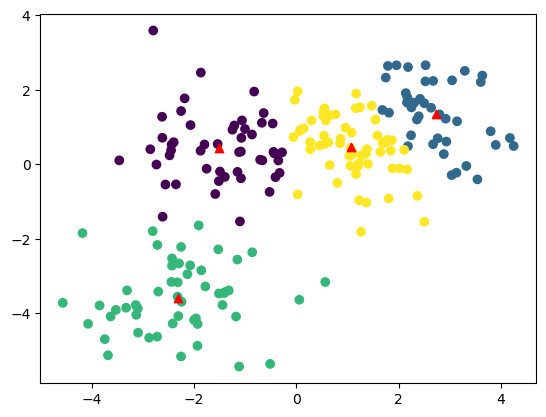

In [6]:
from sklearn.cluster import KMeans

cluster = KMeans(4, n_init=10, init='k-means++')
res = cluster.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=res)
plt.scatter(cluster.cluster_centers_[:,0], cluster.cluster_centers_[:,1], marker='^', c='red')
plt.show()

### 3. Fit the algorithm by varying ```init``` and ```n_init```

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


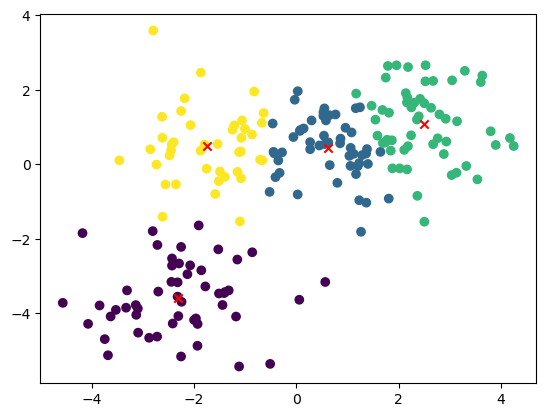

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


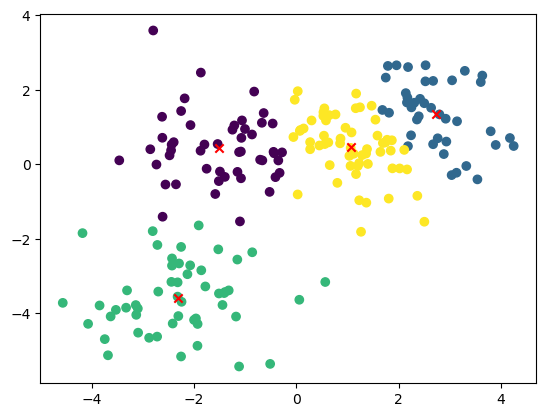

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


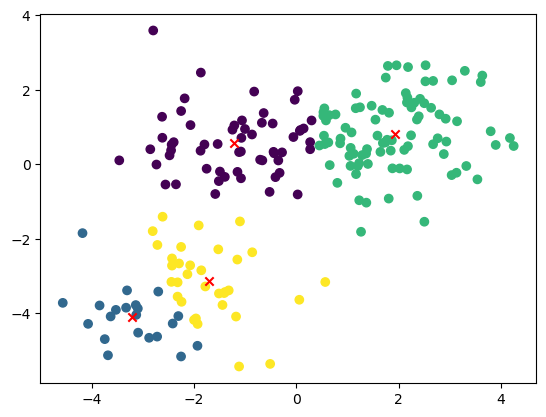

In [ ]:
for i in range(3):
    cluster = KMeans(4, n_init=1, init='k-means++')
    res = cluster.fit_predict(X)
    plt.scatter(X[:,0], X[:,1], c=res)
    plt.scatter(cluster.cluster_centers_[:,0], cluster.cluster_centers_[:,1], marker='x', c='red')
    plt.show()

### K-Means++ Initialization Method

The K-Means++ method is an enhancement of the standard K-Means clustering algorithm. It improves the initialization step of the K-Means algorithm, leading to better clustering results and faster convergence. The main idea behind K-Means++ is to choose initial cluster centers (centroids) in a way that they are spread out as much as possible. This helps in avoiding poor clustering results that can occur due to random initialization of centroids.

### Steps of K-Means++ Initialization:

1. **Randomly select the first centroid** from the data points.
2. **For each remaining centroid**:
    - Compute the distance between each data point and the nearest centroid that has already been chosen.
    - Select the next centroid from the data points with a probability proportional to the square of the distance from the nearest existing centroid. This means that points that are farther away from the existing centroids are more likely to be chosen as the next centroid.
3. **Repeat step 2** until all K centroids are chosen.

### Advantages of K-Means++:

- **Improved Accuracy**: By carefully selecting the initial centroids, K-Means++ often leads to better clustering results compared to random initialization.
- **Faster Convergence**: The algorithm converges faster because the initial centroids are more likely to be close to the optimal solution.


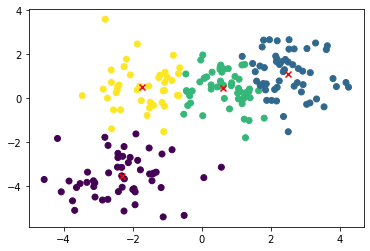

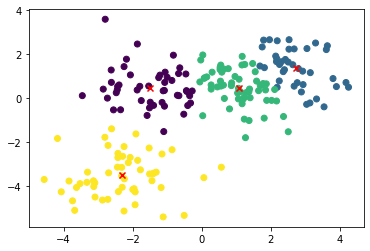

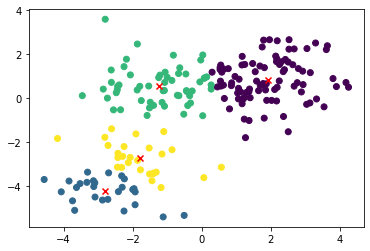

In [6]:
for i in range(3):
    cluster = KMeans(4, n_init=1, init='random')
    res = cluster.fit_predict(X)
    plt.scatter(X[:,0], X[:,1], c=res)
    plt.scatter(cluster.cluster_centers_[:,0], cluster.cluster_centers_[:,1], marker='x', c='red')

    plt.show()

### 4. Fit the algorithm by varying numbers of clusters and plot inertia

In [10]:
from sklearn.metrics import calinski_harabasz_score

def compute_inertias(X):
    inertias = []
    clusters = range(1,12)
    scores = []
    
    for c in clusters:
        cluster = KMeans(c)
        labels = cluster.fit_predict(X)
        inertias.append(cluster.inertia_)        
    return clusters, inertias
    

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avo

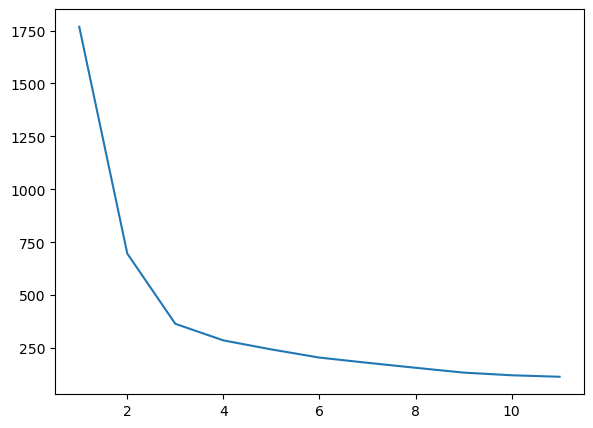

In [11]:
clusters, inertias = compute_inertias(X)
f = plt.figure(figsize=(15,5))
ax = f.add_subplot(121)
ax.plot(clusters, inertias)
plt.show()


Inertia is a measure of how well the K-Means clustering algorithm has clustered the data. It is defined as the sum of squared distances between each data point and the centroid of the cluster to which it belongs. In other words, it quantifies the compactness of the clusters.

Mathematically, inertia is calculated as:

$$\text{Inertia} = \sum_{i=1}^{n} \sum_{j=1}^{k} \delta_{ij} \| x_i - \mu_j \|^2 $$
where:
- $ n $ is the number of data points.
- $ k $ is the number of clusters.
- $ x_i $ is a data point.
- $ \mu_j $ is the centroid of cluster $ j $.
- $ \delta_{ij} $ is an indicator function that is 1 if data point $ x_i $ belongs to cluster $ j $, and 0 otherwise.
- $ \| x_i - \mu_j \|^2 $ is the squared Euclidean distance between data point $ x_i $ and centroid $ \mu_j $.

### Key Points:
- **Lower Inertia**: Indicates more compact clusters, which is generally desirable.
- **Higher Inertia**: Indicates more spread out clusters, which may suggest that the chosen number of clusters is not optimal.

Inertia is often used to determine the optimal number of clusters by plotting the inertia values for different numbers of clusters and looking for an "elbow" point where the rate of decrease sharply slows down. This is known as the "Elbow Method".

### 5. Fit the algorithm by varying numbers of clusters and plot inertia AND calinski_harabasz score

This time search for documentation!

In [12]:
from sklearn.metrics import calinski_harabasz_score

def compute_inertias(X):
    inertias = []
    clusters = range(1,12)
    scores = []
    
    for c in clusters:
        cluster = KMeans(c)
        labels = cluster.fit_predict(X)
        inertias.append(cluster.inertia_)
        if c ==1:
            scores.append(0)
        else:
            scores.append(calinski_harabasz_score(X, labels))
    return clusters, inertias, scores
    

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avo

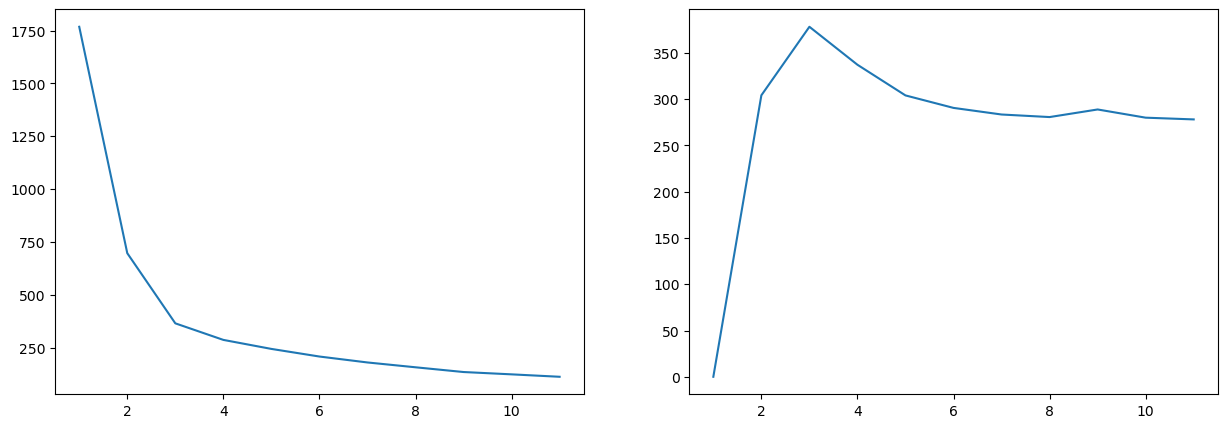

In [13]:
clusters, inertias, scores = compute_inertias(X)
f = plt.figure(figsize=(15,5))
ax = f.add_subplot(121)
ax2 = f.add_subplot(122)
ax.plot(clusters, inertias)
ax2.plot(clusters, scores)
plt.show()

### 6.  Plot as in question 4. and try to guess centers without knowing the value

In [17]:
## please continue after for cycle. Use the given dataset for consistent results across class
centers = [np.random.randint(2,7) for i in range(5)]


c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avo

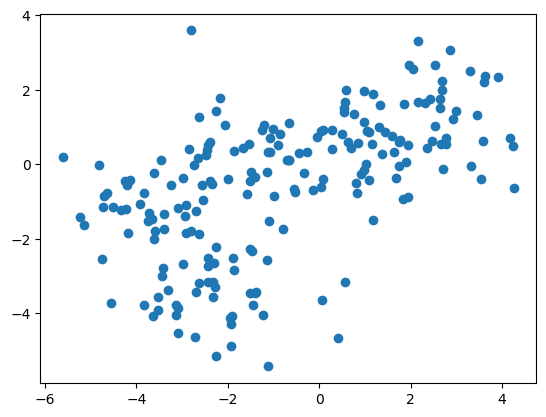

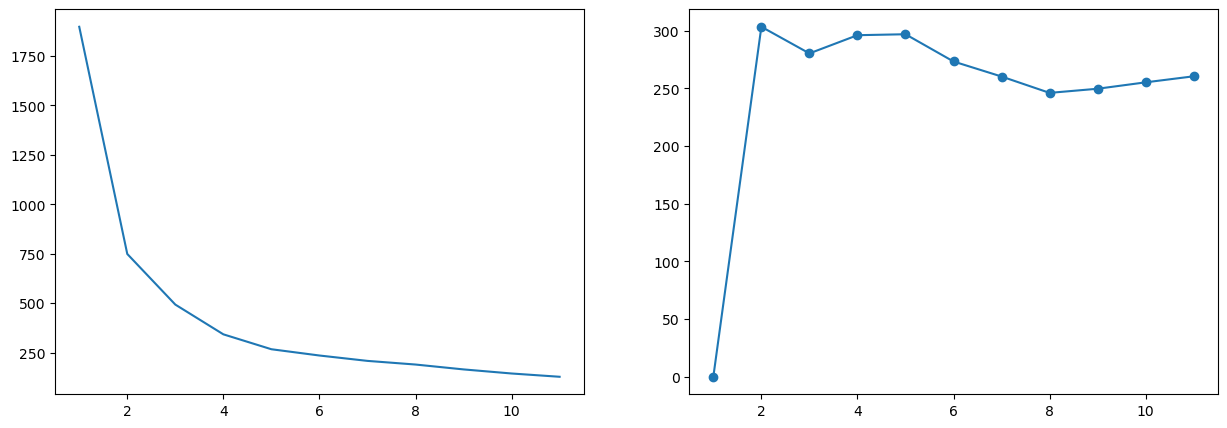

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avo

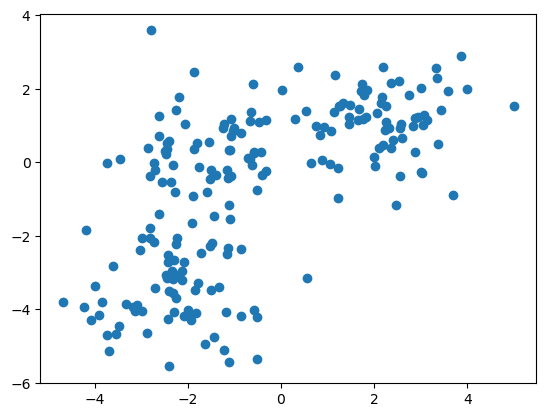

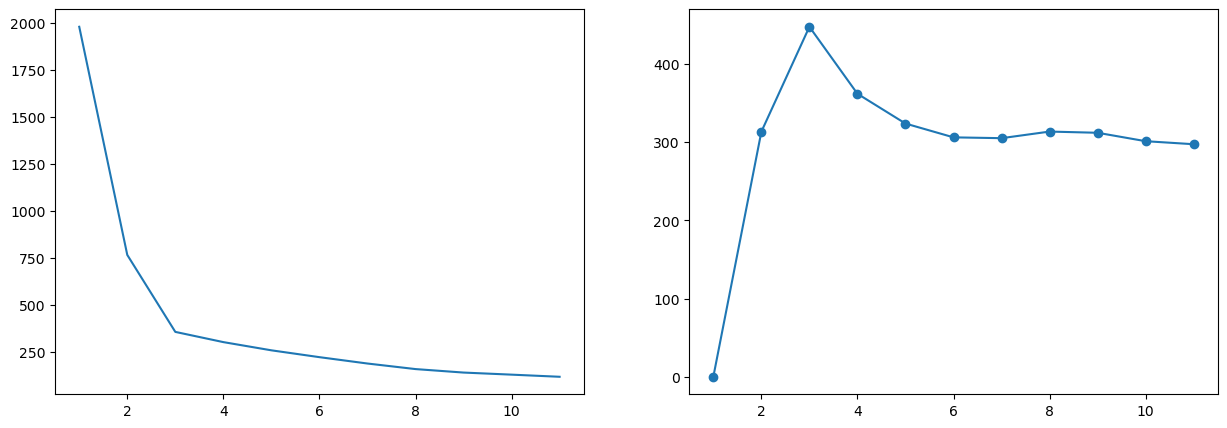

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avo

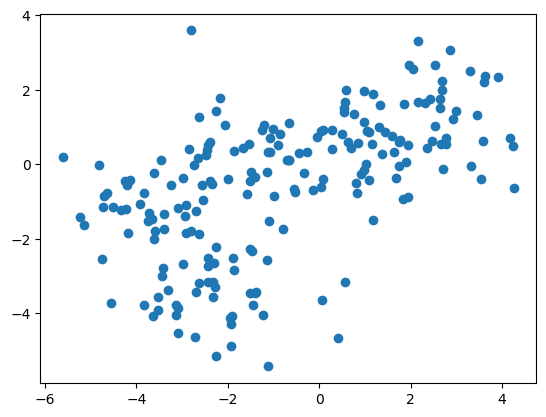

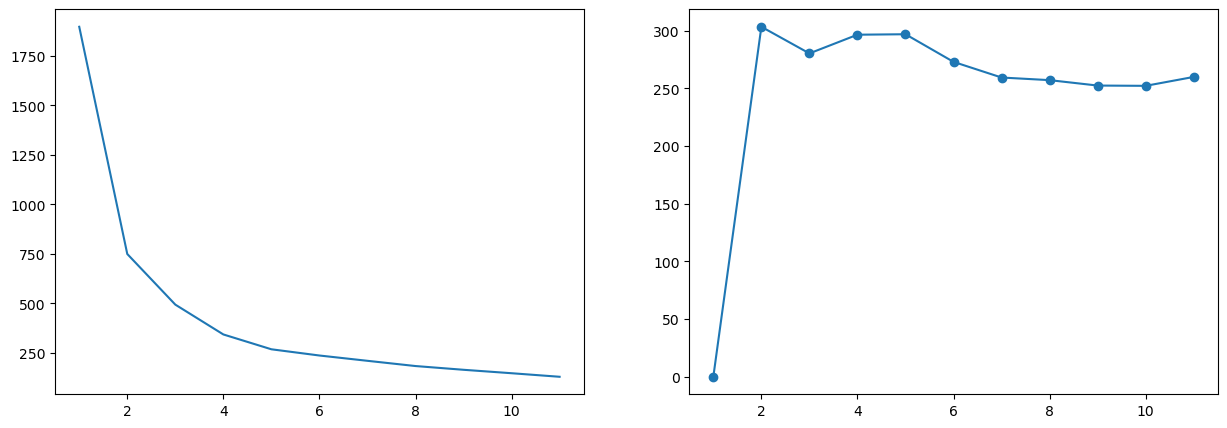

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avo

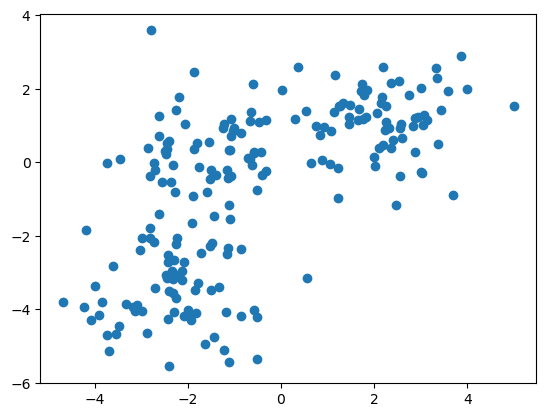

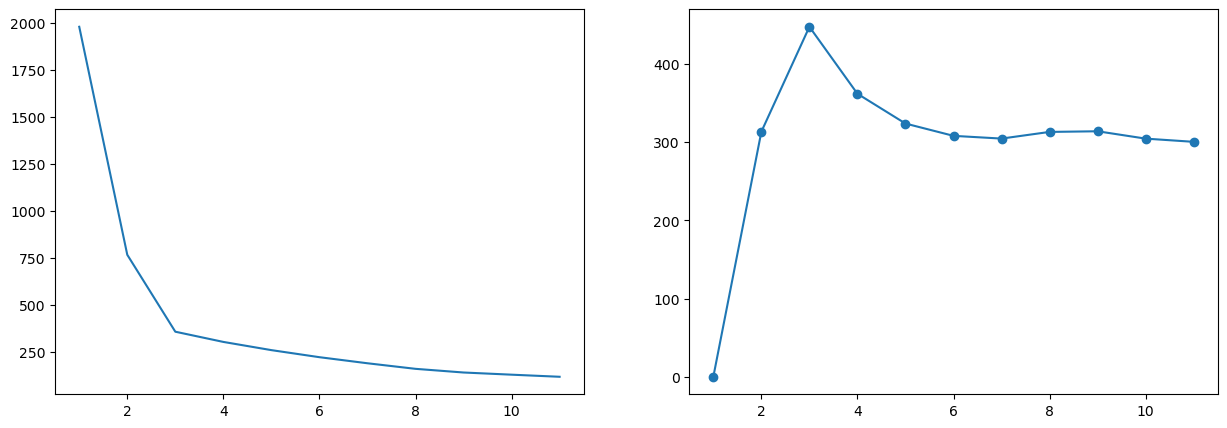

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avo

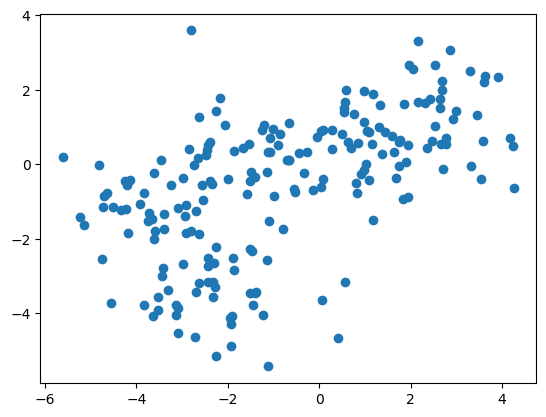

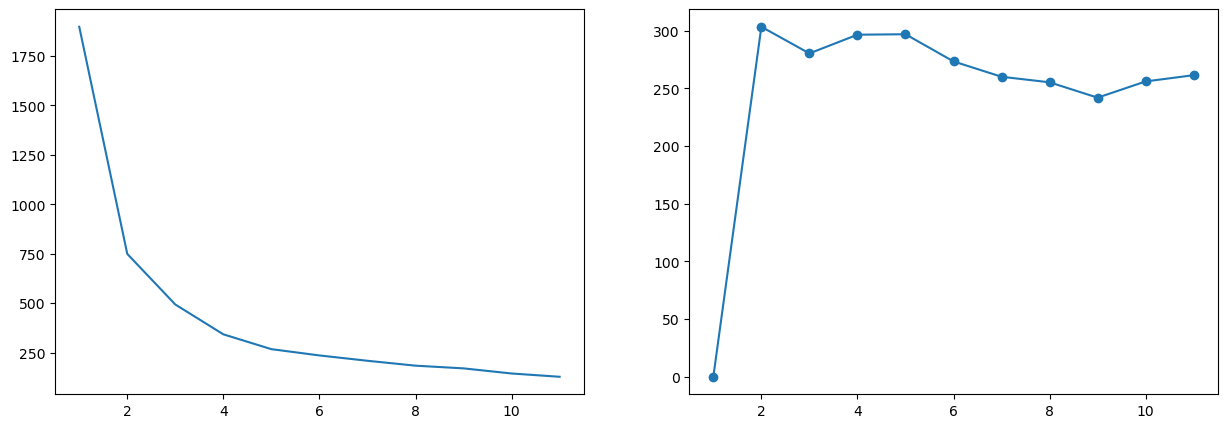

In [18]:

for cluster in centers:
    X, y = make_blobs(n_samples=200, n_features=2, centers=cluster, center_box=(-4,4), random_state=17)
    clusters, inertias, scores = compute_inertias(X)
    plt.scatter(X[:,0], X[:,1])
    f = plt.figure(figsize=(15,5))
    ax = f.add_subplot(121)
    ax2 = f.add_subplot(122)
    ax.plot(clusters, inertias)
    ax2.plot(clusters, scores)
    ax2.scatter(clusters,scores)
    plt.show()

In [19]:
centers

[5, 3, 5, 3, 5]

### 7. Fit a knn model to following dataset and try to guess number of clusters without plotting dataset

In [14]:
np.random.seed(20)

X = [np.random.multivariate_normal((0, 0), cov=([[1,0.5],[10.5,10.5]])) for _ in range(200)]
X.extend([np.random.multivariate_normal((4, -4), cov=([[1,0],[0,1]])) for _ in range(20)])
X.extend([np.random.multivariate_normal((-4, 4), cov=([[0.1,0.2],[0.3,0.4]])) for _ in range(50)])
X = np.array(X)

<ipython-input-14-2a8c26343156>:3: RuntimeWarning: covariance is not positive-semidefinite.
  X = [np.random.multivariate_normal((0, 0), cov=([[1,0.5],[10.5,10.5]])) for _ in range(200)]
<ipython-input-14-2a8c26343156>:5: RuntimeWarning: covariance is not positive-semidefinite.
  X.extend([np.random.multivariate_normal((-4, 4), cov=([[0.1,0.2],[0.3,0.4]])) for _ in range(50)])


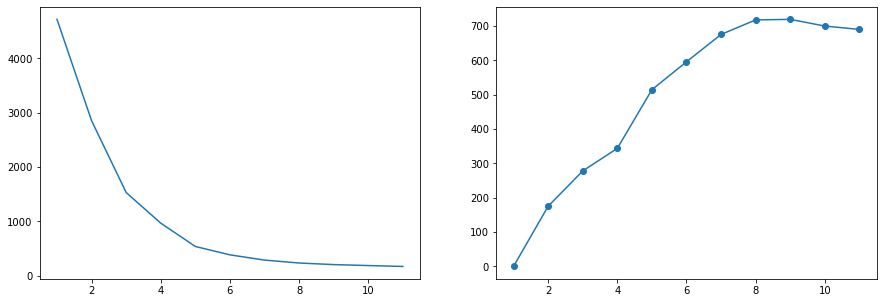

In [15]:
score = []

clusters, inertias, scores = compute_inertias(X)
f = plt.figure(figsize=(15,5))
ax = f.add_subplot(121)
ax2 = f.add_subplot(122)
ax.plot(clusters, inertias)
ax2.plot(clusters, scores)
ax2.scatter(clusters,scores)
plt.show()

## 8. Business tells you that dataset should have 3 classes: apply kmeans to find clusters and plot result

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


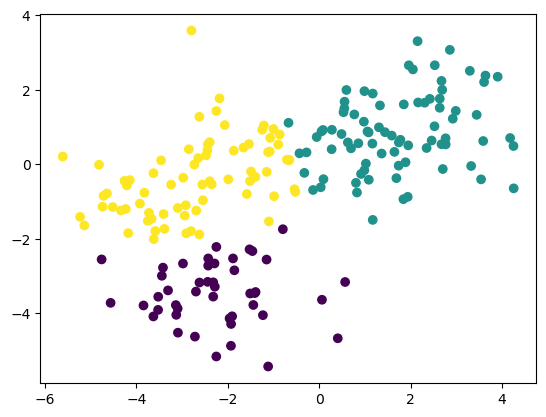

In [20]:
cluster = KMeans(3)
labels = cluster.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)

## 9. Fit a Gaussian Mixture Model 

[gaussian mixture model](https://scikit-learn.org/0.16/modules/generated/sklearn.mixture.GMM.html)

In [21]:
from sklearn.mixture import GaussianMixture

def compute_inertias_gmm(X):
    clusters = range(1,12)
    scores = []
    
    for c in clusters:
        gmm = GaussianMixture(c)
        labels = gmm.fit_predict(X)
        if c ==1:
            scores.append(0)
        else:
            scores.append(gmm.bic(X))
    return clusters, scores
    

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

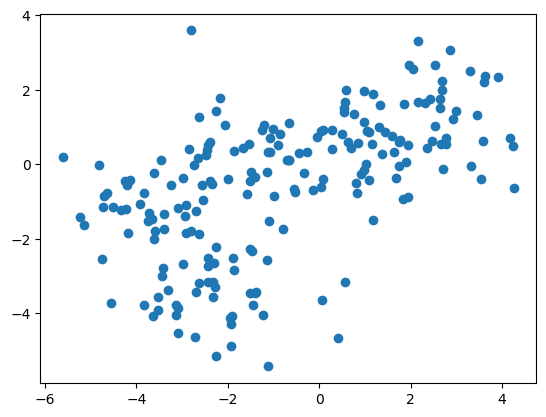

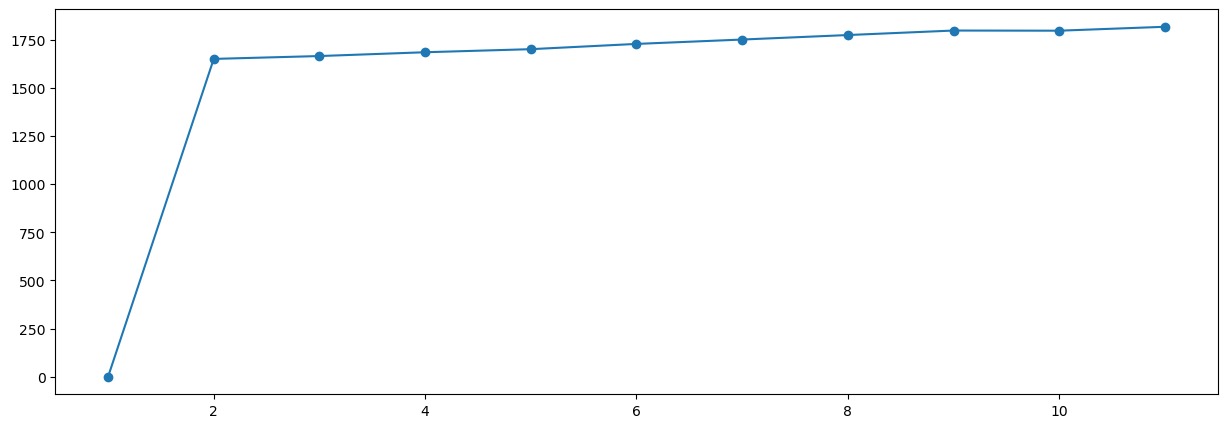

In [22]:
score = []

clusters, scores = compute_inertias_gmm(X)

plt.scatter(X[:,0], X[:,1])
plt.figure(figsize=(15,5))
plt.plot(clusters, scores)
plt.scatter(clusters,scores)
plt.show()

c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


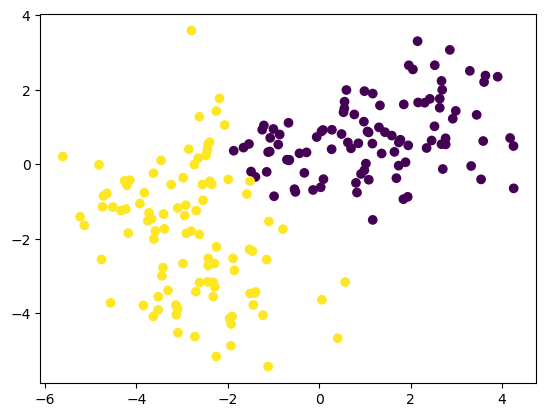

In [23]:
gmm = GaussianMixture(2)
labels = gmm.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)


c:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


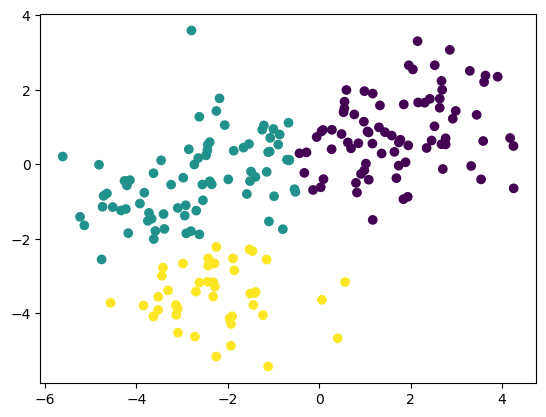

In [24]:
gmm = GaussianMixture(3)
labels = gmm.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=labels)